In [5]:
import torch
import scanpy as sc
import numpy as np
import os
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import scipy.cluster.hierarchy as sch
import mmg
from mmg.model import RMGE 
from mmg.integration import HomologyMapper,CrossSpeciesAligner


In [2]:
merged_data = sc.read_h5ad('test_data/mouse_human_brain_samp.h5ad')


In [3]:
sc.pp.normalize_total(merged_data, target_sum=1e4) 
sc.pp.log1p(merged_data)   

In [4]:
# #############################################optional#############################################
sc.pp.highly_variable_genes(merged_data, n_top_genes=3000)
merged_data = merged_data[:, merged_data.var['highly_variable']]

#############################################optional#############################################
# The number of cells must be greater than 500
# Suitable for Stereo seq, MERFISH, StarMAP and other technologies
#################################################################################################
# sn_data = merged_data[merged_data.obs['species']=='Human']
# st_data = merged_data[merged_data.obs['species']=='Mouse']

# sc.tl.pca(sn_data, n_comps=500)

# pca_weights = sn_data.varm['PCs']  # numpy array (n_genes, n_comps)

# st_matrix = torch.tensor(st_data.X.toarray()).float()  
# pca_weights_torch = torch.tensor(np.copy(pca_weights)).float()

# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# st_matrix = st_matrix.to(device)
# pca_weights_torch = pca_weights_torch.to(device)

# st_pca = torch.matmul(st_matrix, pca_weights_torch).cpu().numpy().astype(np.float64)
# sn_data.obsm['X_pca'] = sn_data.obsm['X_pca'].astype(np.float64)

# st_pca_corr = []
# for i in range(st_pca.shape[1]):
#     pcs = (st_pca[:,i]-st_pca[:,i].mean())/st_pca[:,i].std()*sn_data.obsm['X_pca'][:,i].std()+sn_data.obsm['X_pca'][:,i].mean()
#     st_pca_corr.append(pcs)
# st_data.obsm['X_pca'] = np.array(st_pca_corr).T

# st_data_pca = sc.AnnData(X=st_data.obsm['X_pca'],obs=st_data.obs,obsm=st_data.obsm)
# sn_data_pca = sc.AnnData(X=sn_data.obsm['X_pca'],obs=sn_data.obs,obsm=sn_data.obsm)

# merged_data = sc.concat([sn_data_pca,st_data_pca])

In [5]:

species_list = ['Mouse', 'Human']
rmge_list={}
weight={}

for sp in species_list:
    sub_merged_data1,sub_merged_data2 = merged_data[merged_data.obs['species']==sp], merged_data[merged_data.obs['species']!=sp]
    sub_merged_data2.X = sub_merged_data2.X*(sub_merged_data1.X.mean(axis=0)/(sub_merged_data2.X.mean(axis=0)+1e-50))
    rmge = RMGE(sub_merged_data1,sub_merged_data2, device='cuda',class_columns = 'SubClass',kl_weight=0)
    train_losses, train_accuracies = rmge.train(epochs=500)
    rmge_list[sp]=rmge
    weight[sp] = rmge_list[sp].model.fc.weight.cpu().detach().numpy()




Epoch 0/500, Loss: 14.723735809326172, Accuracy: 1.0
Epoch 100/500, Loss: 0.6756657958030701, Accuracy: 1.0
Epoch 200/500, Loss: 0.6002237200737, Accuracy: 1.0
Epoch 300/500, Loss: 0.6033304333686829, Accuracy: 1.0
Epoch 400/500, Loss: 0.6002029776573181, Accuracy: 1.0
Epoch 0/500, Loss: 15.717300415039062, Accuracy: 0.8888888888888888
Epoch 100/500, Loss: 1.2325993776321411, Accuracy: 1.0
Epoch 200/500, Loss: 1.155280590057373, Accuracy: 1.0
Epoch 300/500, Loss: 1.155196189880371, Accuracy: 1.0
Epoch 400/500, Loss: 1.2212036848068237, Accuracy: 1.0


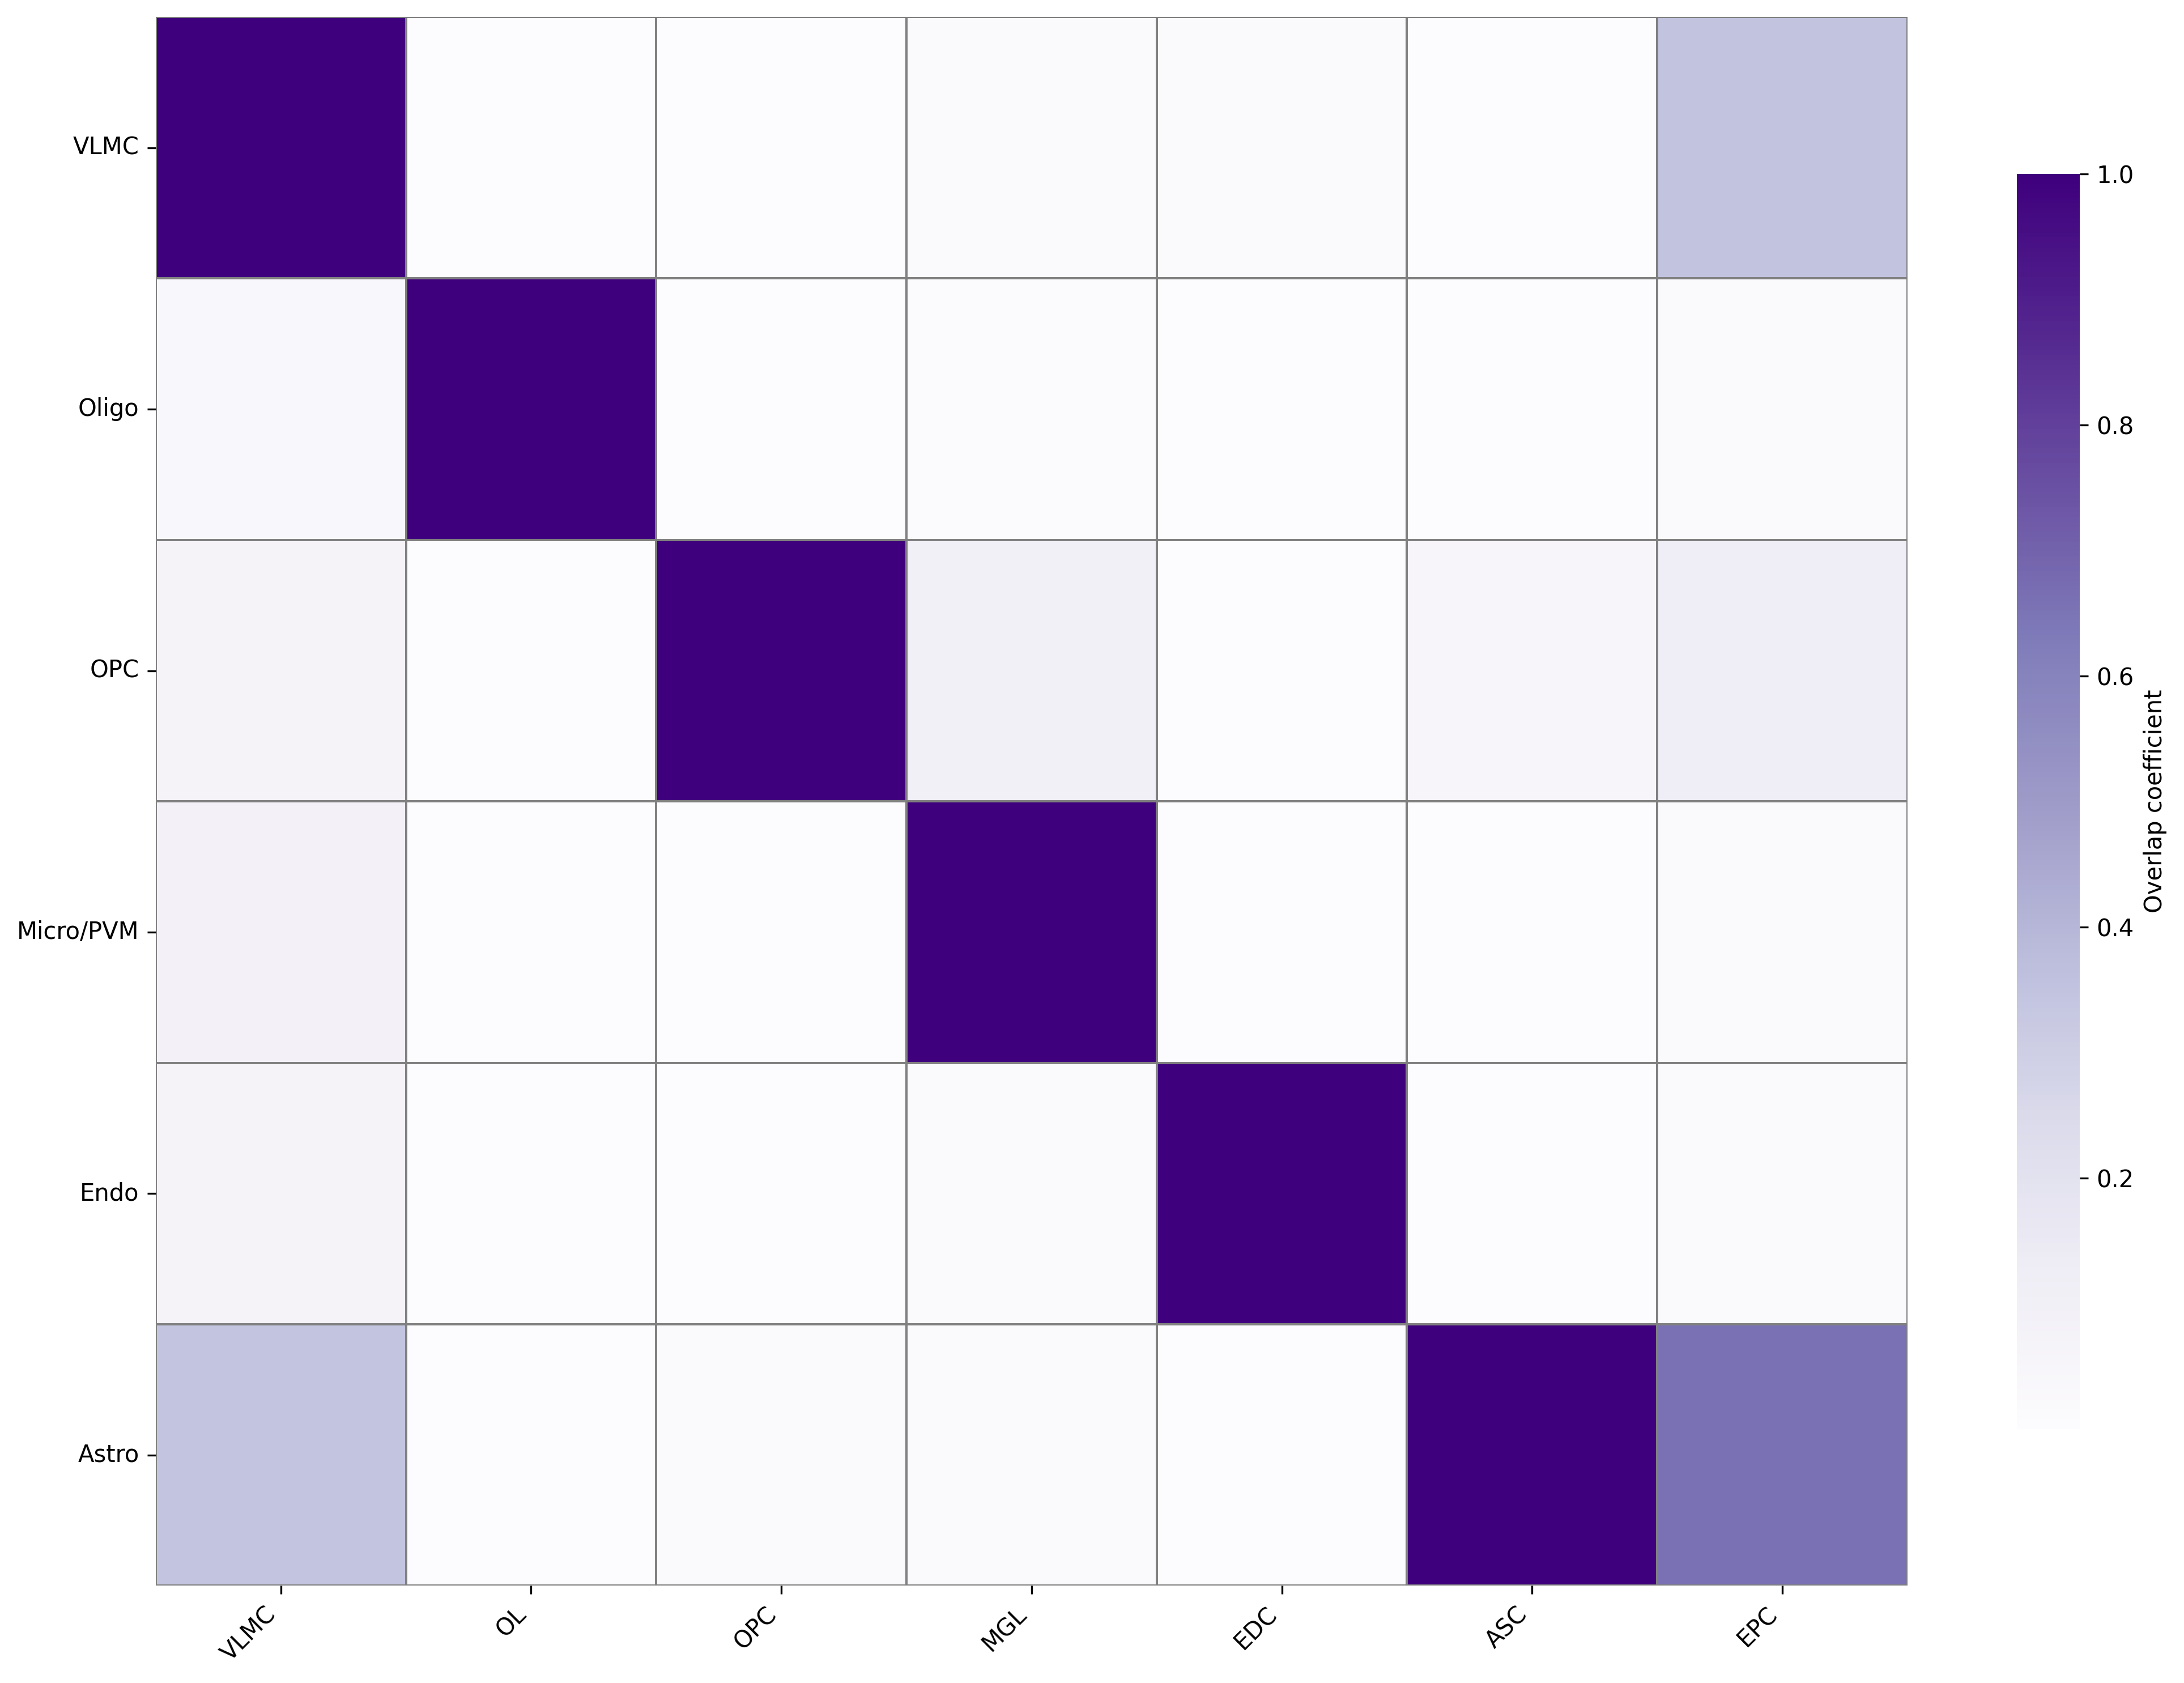

In [6]:

mapper = HomologyMapper(
    merged_data=merged_data,
    rmge_list=rmge_list,
    species_pair=['Human', 'Mouse'],
    cell_type_col='SubClass',
    overlap_threshold=0.6,
    adjusted_diff_threshold=0.5,
    device='cuda'
)

# 执行同源性映射
merged_data_homologous = mapper.compute_homology()
mapper.plot_consensus_heatmap()

In [8]:


species_list = ['Human','Mouse']

rmge_list={}
weight={}

for sp in species_list:
    rmge = RMGE(merged_data_homologous[merged_data_homologous.obs['species']==sp], merged_data_homologous[merged_data_homologous.obs['species']!=sp], device='cuda',class_columns = 'predict',kl_weight=0,dropout_rate=0.8)
    train_losses, train_accuracies = rmge.train(epochs=500)
    predict_class_names = rmge.evaluate()
    rmge_list[sp]=rmge
    weight[sp] = rmge_list[sp].model.fc.weight.cpu().detach().numpy()





Epoch 0/500, Loss: 15.628767013549805, Accuracy: 0.9027777777777778
Epoch 100/500, Loss: 1.245675802230835, Accuracy: 1.0
Epoch 200/500, Loss: 1.1530835628509521, Accuracy: 1.0
Epoch 300/500, Loss: 1.1687653064727783, Accuracy: 1.0
Epoch 400/500, Loss: 1.1598339080810547, Accuracy: 1.0
Validation Accuracy: 1.0000
Epoch 0/500, Loss: 14.708587646484375, Accuracy: 1.0
Epoch 100/500, Loss: 0.6624253988265991, Accuracy: 1.0
Epoch 200/500, Loss: 0.5919357538223267, Accuracy: 1.0
Epoch 300/500, Loss: 0.5850558280944824, Accuracy: 1.0
Epoch 400/500, Loss: 0.6006938815116882, Accuracy: 1.0
Validation Accuracy: 1.0000


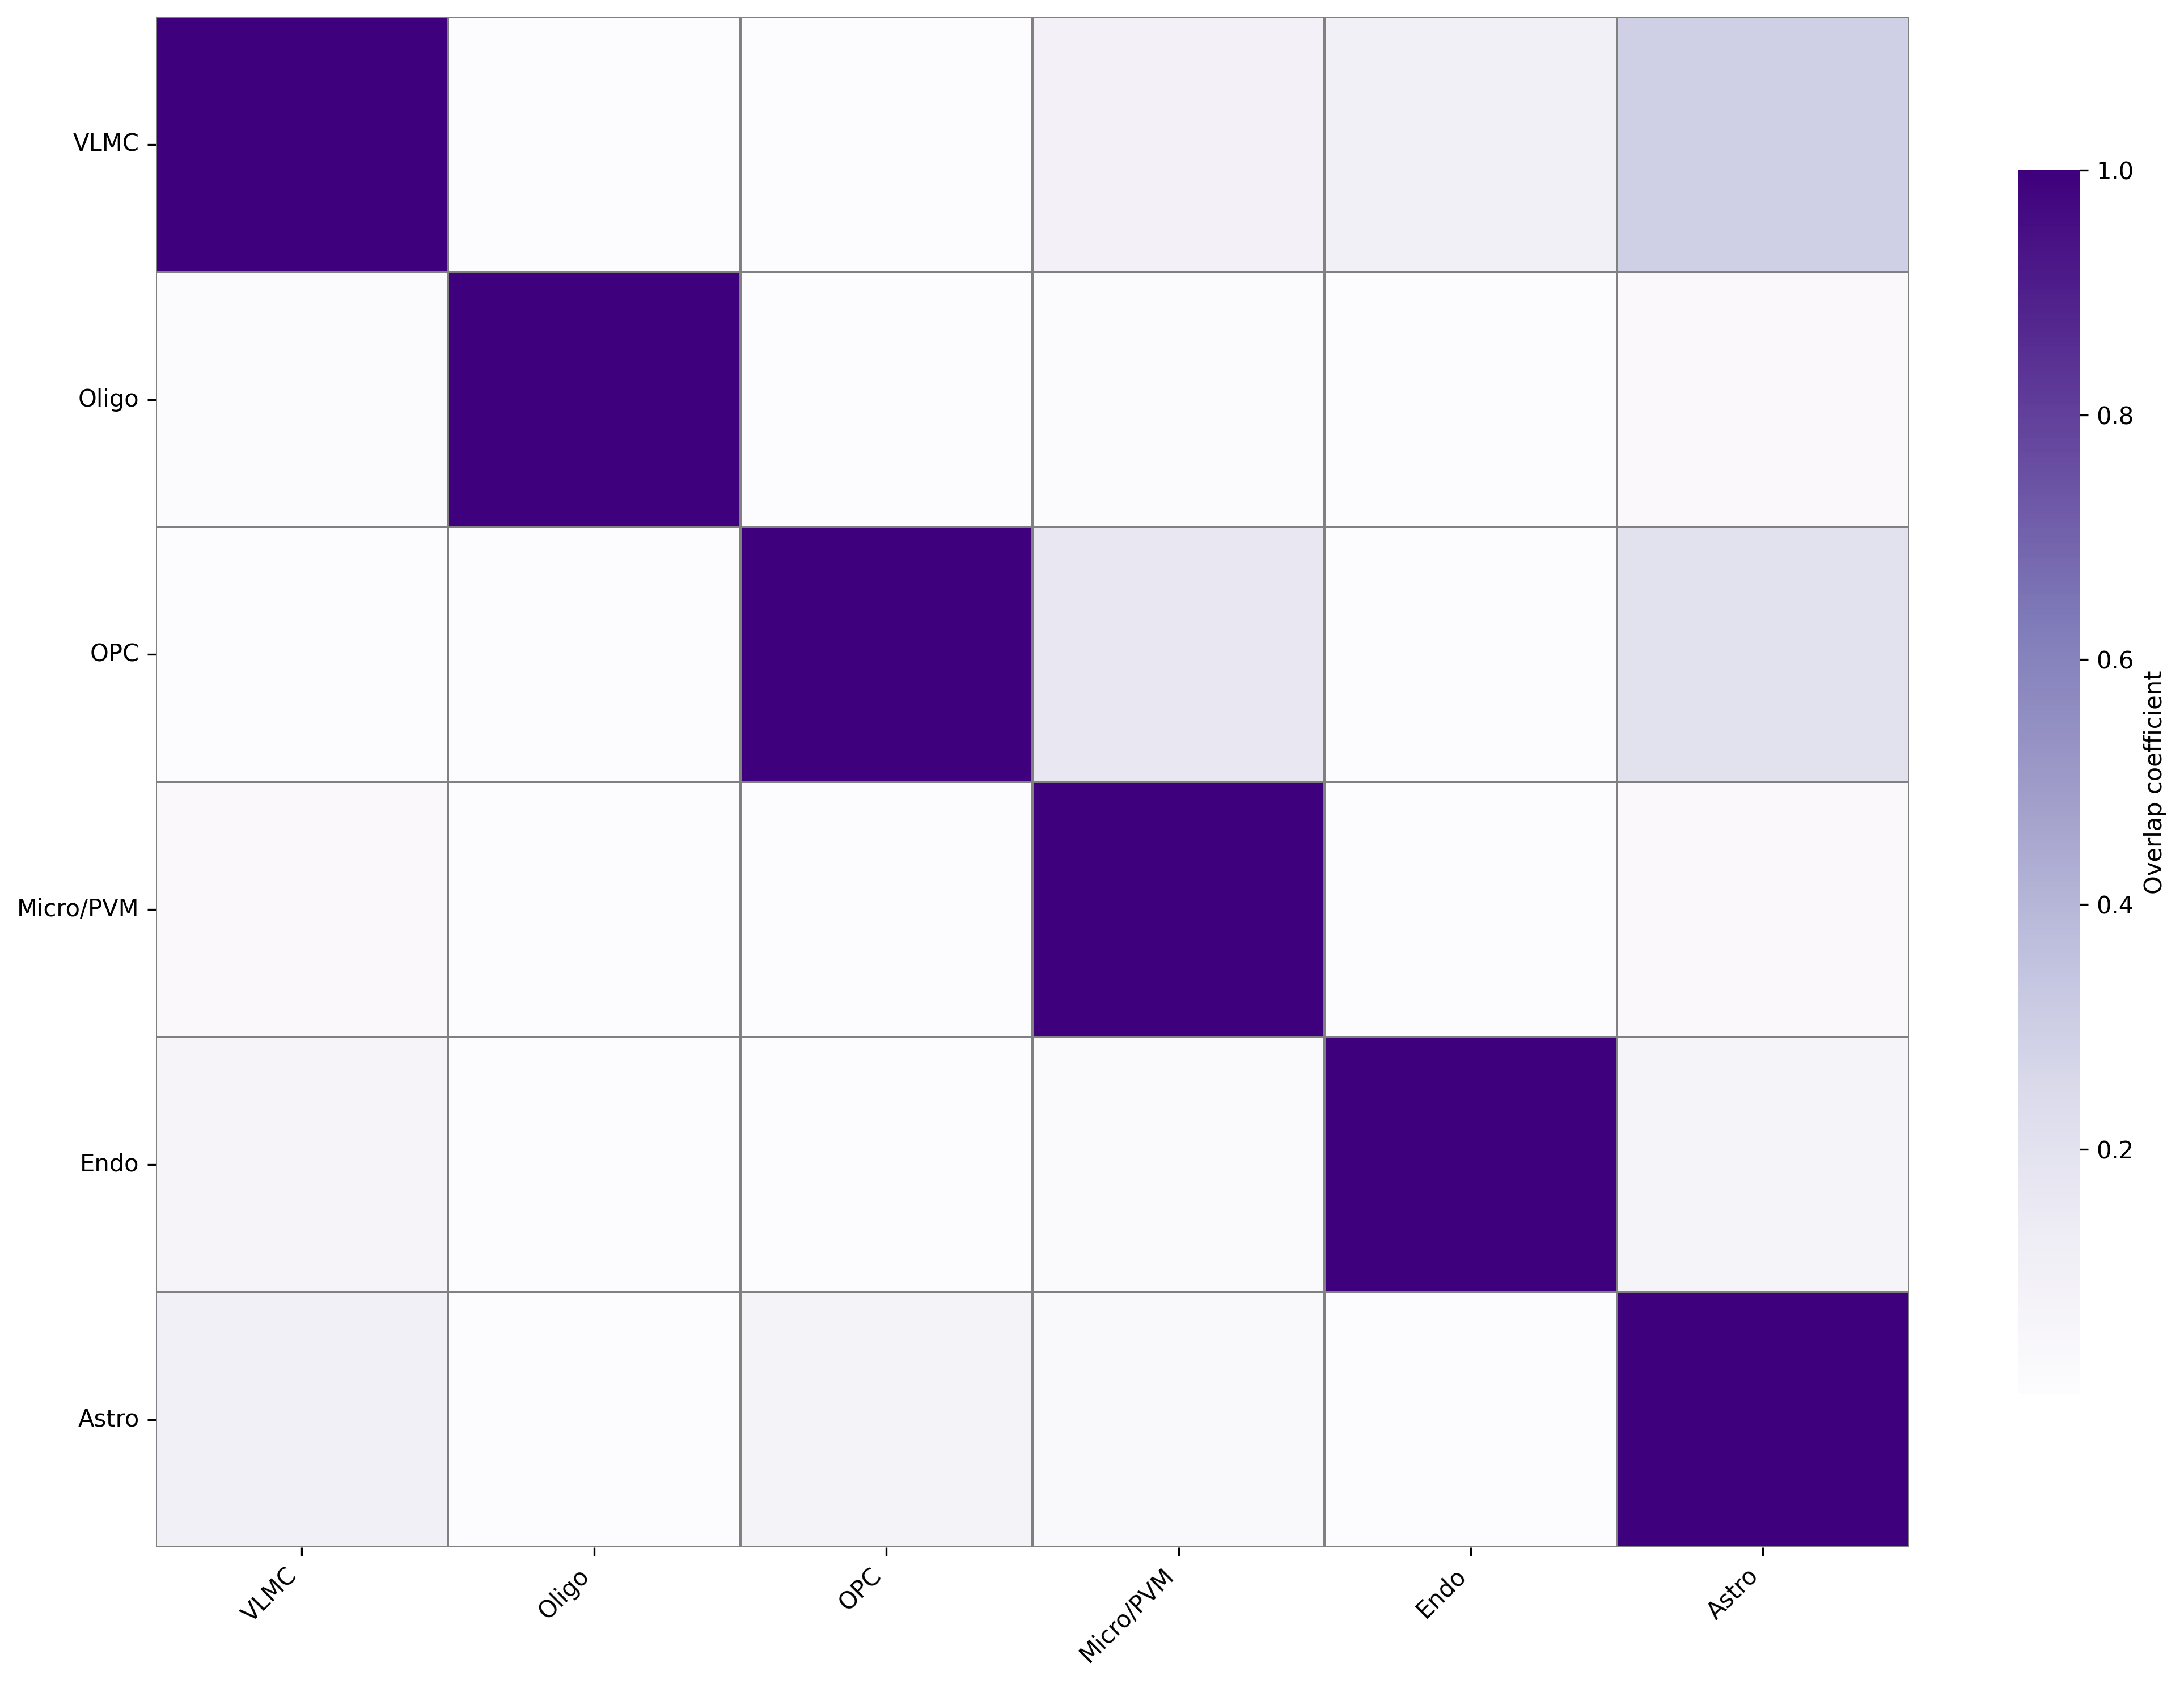

In [9]:

mapper_refined = HomologyMapper(
    merged_data=merged_data_homologous,     
    rmge_list=rmge_list,
    species_pair=['Human', 'Mouse'],       
    cell_type_col='predict',              
    overlap_threshold=0.6,
    device='cuda'
)

merged_homologous_v2 = mapper_refined.compute_homology()
mapper_refined.plot_consensus_heatmap()


Processing subclass: Astro for species Human
Processing subclass: Endo for species Human
Processing subclass: Micro/PVM for species Human
Processing subclass: Oligo for species Human
Processing subclass: OPC for species Human
Processing subclass: VLMC for species Human
Processing subclass: Astro for species Mouse
Processing subclass: Endo for species Mouse
Processing subclass: Micro/PVM for species Mouse
Processing subclass: OPC for species Mouse
Processing subclass: Oligo for species Mouse
Processing subclass: VLMC for species Mouse


/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/sklearn/manifold/_spectral_embedding.py:273: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


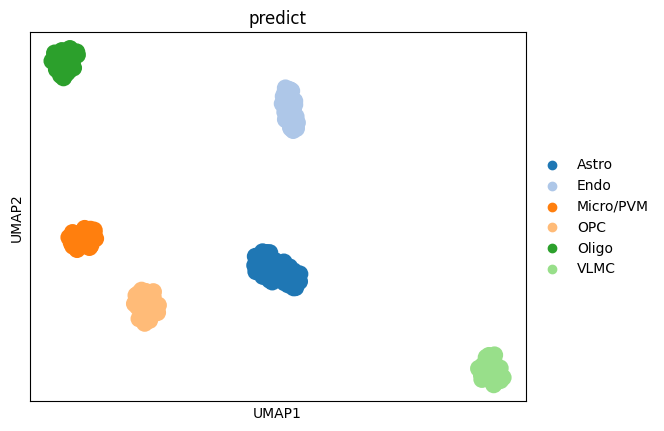

/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


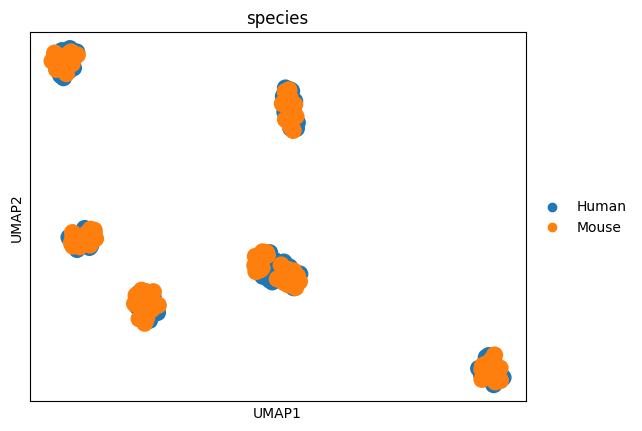

/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


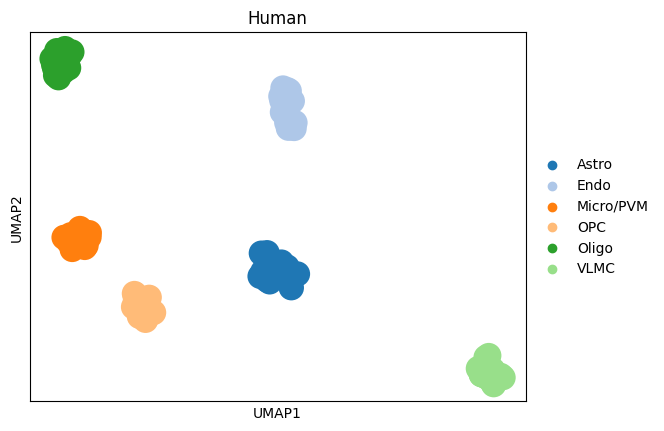

/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_utils.py:430: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list
/cluster/home/sunyk/anaconda3/envs/cuda7/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


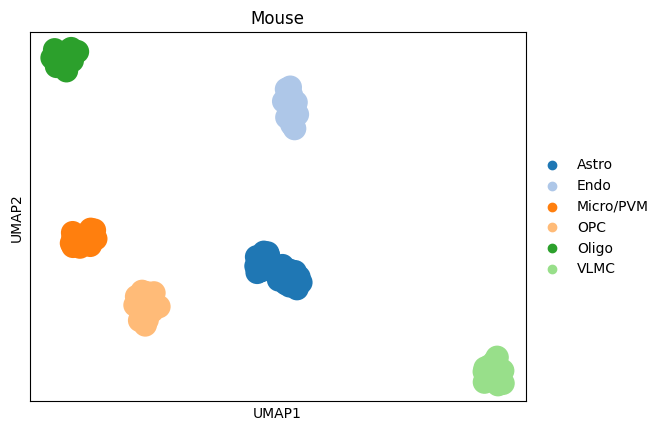

In [10]:


aligner = CrossSpeciesAligner(
    merged_data_homologous=merged_data_homologous,
    rmge_list=rmge_list,
    species_list=['Human', 'Mouse'],
    device='cuda',
    predict_col='predict'
)

combined_data = aligner.align()
aligner.run_umap()